## import et création du dataset 

In [14]:

import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# affichage plus propre
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

# extraction du zip
local_zip = '../Project 2026 dataset.zip'

with zipfile.ZipFile(local_zip, 'r') as zip_ref:
    zip_ref.extractall('')

# chemin du fichier train.csv
train_csv_path = os.path.join(
    './student_dataset',
    'student_failure',
    'train.csv'
)

print(train_csv_path)

./student_dataset/student_failure/train.csv


## Structure générale du dataset

Observons les données qui se trouvent dans notre dataset. On va chercher :

- le nombre de lignes
- le nombre de colonnes
- les types de variables
- les colonnes potentiellement inutiles
- la variable cible

### Aperçu des premières lignes


In [ ]:
df = pd.read_csv(train_csv_path)

print("Dataset chargé avec succès : ", df.shape[0], "lignes et", df.shape[1], "colonnes")


# Affichage des premières lignes du dataset
print(df.head())

Dataset chargé avec succès :  630000 lignes et 15 colonnes
   id  age   genre              diplôme  heures_etude  assiduité_classe  \
0   0   21    male     Computer Science          7.91              98.8   
1   1   18  female                  Law          4.95              94.8   
2   2   20  female     Computer Science          4.68              92.6   
3   3   19    male     Computer Science          2.00              49.5   
4   4   23  female  Business Management          7.65              86.9   

  accès_internet  heures_sommeil qualité_sommeil  méthode_etude  \
0            NaN             4.9         average  online videos   
1            yes             4.7            poor     self-study   
2            NaN             5.8            poor       coaching   
3            yes             8.3         average    group study   
4            yes             9.6            good     self-study   

  évaluation_établissement difficulté_examen  score_examen  heures_fête  \
0           

La variable cible de notre projet est **"score_examen"**.

 
### Statistiques descriptives (variables numériques) :

In [27]:

# Affichage des informations sur les types de données 
print(df.info())


print("\n\n\n\n\ndescription du dataset :")
# Affichage des statistiques descriptives pour les colonnes numériques et catégorielles
df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id                        630000 non-null  int64  
 1   age                       630000 non-null  int64  
 2   genre                     630000 non-null  str    
 3   diplôme                   630000 non-null  str    
 4   heures_etude              611100 non-null  float64
 5   assiduité_classe          630000 non-null  float64
 6   accès_internet            567000 non-null  str    
 7   heures_sommeil            630000 non-null  float64
 8   qualité_sommeil           630000 non-null  str    
 9   méthode_etude             585900 non-null  str    
 10  évaluation_établissement  630000 non-null  str    
 11  difficulté_examen         630000 non-null  str    
 12  score_examen              630000 non-null  float64
 13  heures_fête               630000 non-null  int64  
 14 

,id,age,genre,diplôme,heures_etude,assiduité_classe,accès_internet,heures_sommeil,qualité_sommeil,méthode_etude,évaluation_établissement,difficulté_examen,score_examen,heures_fête,taille_etudiant
count,630000.000000,630000.000000,630000,630000,611100.000000,630000.000000,567000,630000.000000,630000,585900,630000,630000,630000.000000,630000.000000,630000.000000
unique,NaN,NaN,2,7,NaN,NaN,2,NaN,3,5,3,3,NaN,NaN,NaN
top,NaN,NaN,male,Engineering,NaN,NaN,yes,NaN,poor,coaching,medium,moderate,NaN,NaN,NaN
freq,NaN,NaN,365662,131236,NaN,NaN,521430,NaN,213675,122444,214082,353982,NaN,NaN,NaN
mean,314999.500000,20.545821,NaN,NaN,4.002779,71.987261,NaN,7.072758,NaN,NaN,NaN,NaN,63.406789,4.000514,1.754836
std,181865.479132,2.260238,NaN,NaN,2.359388,17.430098,NaN,1.744811,NaN,NaN,NaN,NaN,18.950840,2.000382,0.131891
min,0.000000,17.000000,NaN,NaN,0.080000,40.600000,NaN,4.100000,NaN,NaN,NaN,NaN,12.600000,0.000000,1.480000
25%,157499.750000,19.000000,NaN,NaN,1.980000,57.000000,NaN,5.600000,NaN,NaN,NaN,NaN,49.600000,3.000000,1.660000
50%,314999.500000,21.000000,NaN,NaN,4.010000,72.600000,NaN,7.100000,NaN,NaN,NaN,NaN,63.620000,4.000000,1.750000
75%,472499.250000,23.000000,NaN,NaN,6.050000,87.200000,NaN,8.600000,NaN,NaN,NaN,NaN,77.300000,5.000000,1.850000


### On va aussi vérifier si nous avons des doublons : 

In [28]:
print("Nombre de doublons :", df.duplicated().sum())

Nombre de doublons : 0




# 2. Exploratory Data Analysis (EDA)

## Analyse de la variable cible : `score_examen`

Avant de construire un modèle, il serait intéressant de comprendre la distribution des notes.

On va chercher à répondre à plusieurs questions :

- les notes sont-elles équilibrées ?
- y a-t-il beaucoup d’échecs ?
- la distribution est-elle normale ?
- y a-t-il des valeurs aberrantes ?

Cette partie est importante car elle donne déjà une vision métier de la situation scolaire.


## Distribution des notes

Nous voulons observer si beaucoup d’étudiants échouent (< 50). Mais aussi si la distribution est centrée et si certaines valeurs semblent anormales.



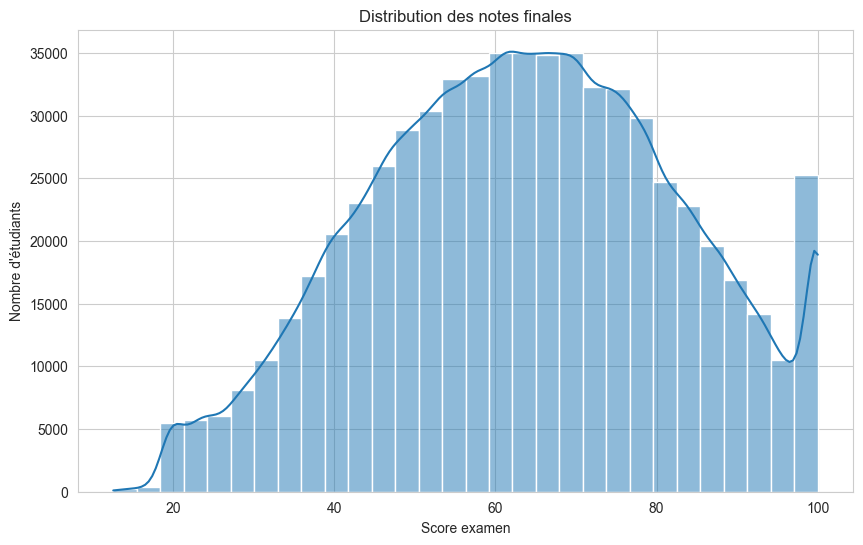

Moyenne : 63.41
Médiane : 63.62
Variance : 359.13
Étudiants en échec : 161083
Étudiants en réussite : 468917


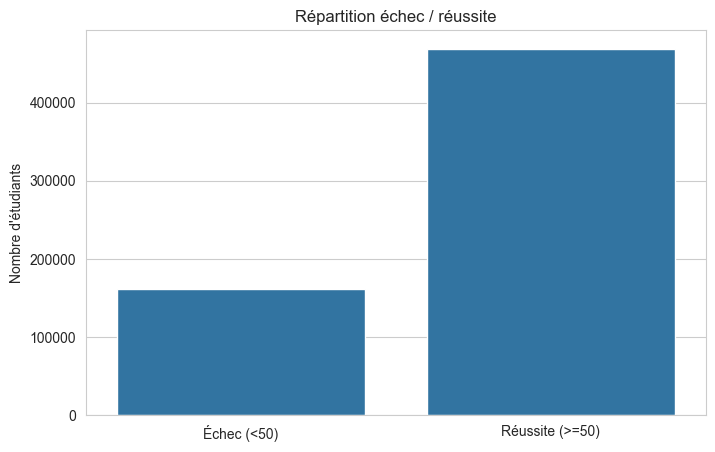

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(df["score_examen"], bins=30, kde=True)

plt.title("Distribution des notes finales")
plt.xlabel("Score examen")
plt.ylabel("Nombre d'étudiants")

plt.show()


# on peut déjà récupérer les valeurs médianes aussi :
mean_score = df["score_examen"].mean()
median_score = df["score_examen"].median()
variance_score = df["score_examen"].var()

print(f"Moyenne : {mean_score:.2f}")
print(f"Médiane : {median_score:.2f}")
print(f"Variance : {variance_score:.2f}")


# étudiants en échec : score_examen < 50

fail_count = (df["score_examen"] < 50).sum()
success_count = (df["score_examen"] >= 50).sum()

print("Étudiants en échec :", fail_count)
print("Étudiants en réussite :", success_count)

labels = ["Échec (<50)", "Réussite (>=50)"]
values = [fail_count, success_count]

plt.figure(figsize=(8, 5))

sns.barplot(x=labels, y=values)

plt.title("Répartition échec / réussite")
plt.ylabel("Nombre d'étudiants")

plt.show()

à compléter : interpréation des graph et donées

### à compléter : intérêt d'un boxplot ?

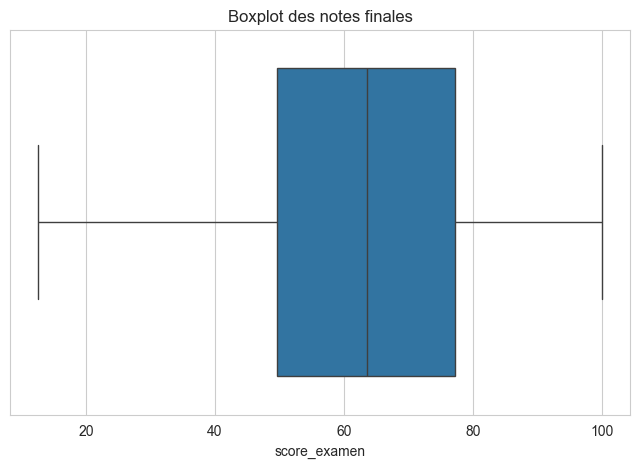

In [33]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["score_examen"])

plt.title("Boxplot des notes finales")

plt.show()